Approximate constrained optimum x*:
x1* = -1.718045
x2* = 0.557644
f(x*) = 6.214325
g(x*) = -0.009336


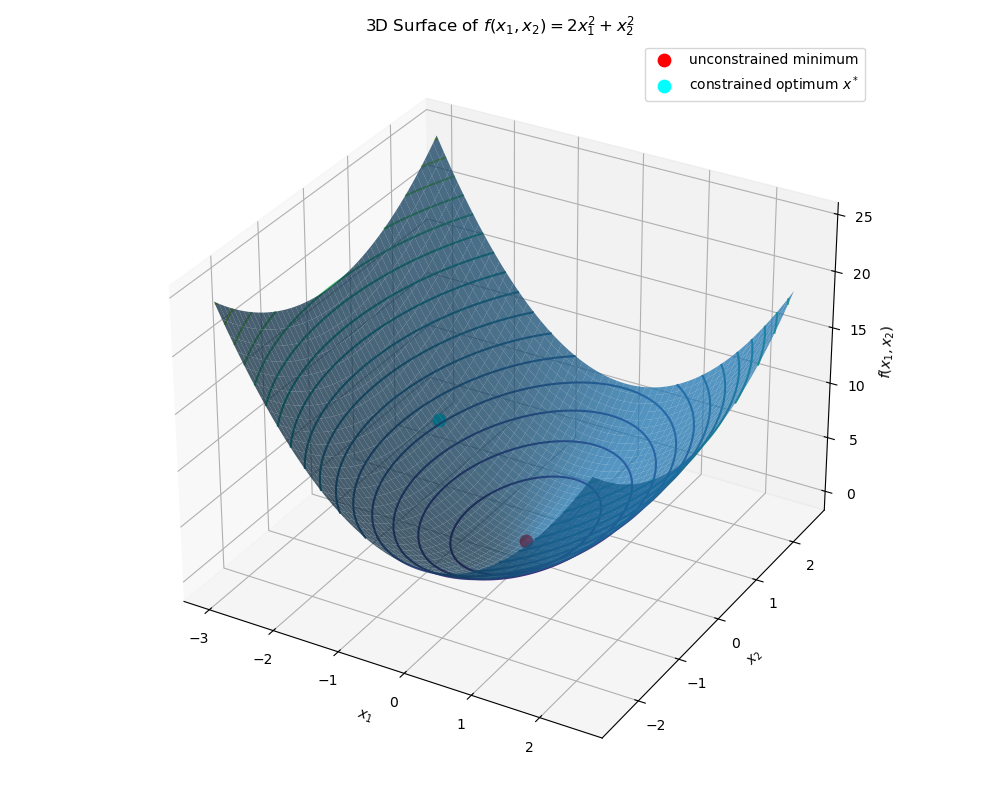

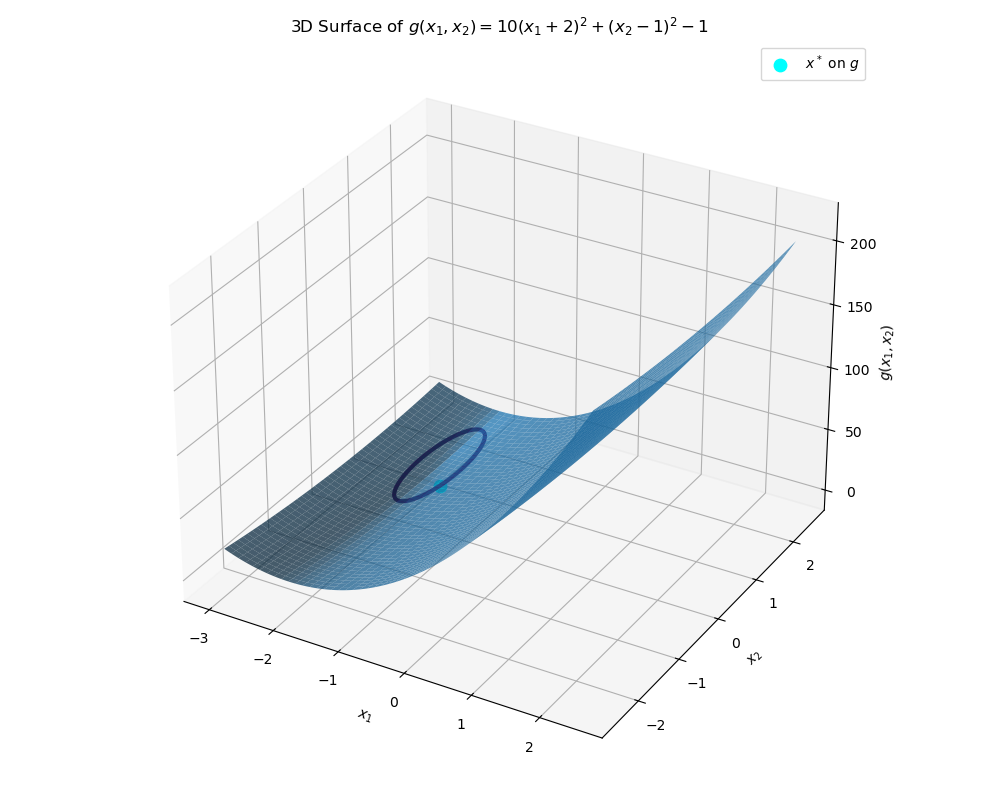

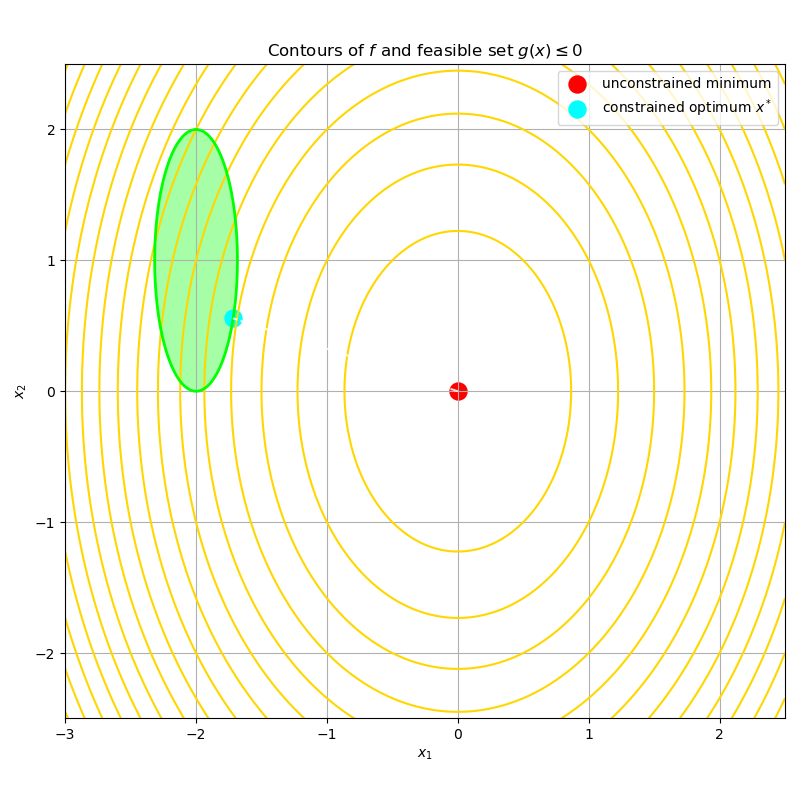

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Define the functions from the slide
# ==========================================
def f(x1, x2):
    return 2 * x1**2 + x2**2

def g(x1, x2):
    return 10 * (x1 + 2)**2 + (x2 - 1)**2 - 1


# ==========================================
# 2. Build grid
# ==========================================
x1 = np.linspace(-3.0, 2.5, 400)
x2 = np.linspace(-2.5, 2.5, 400)
X1, X2 = np.meshgrid(x1, x2)

F = f(X1, X2)
G = g(X1, X2)

# feasible set
feasible_mask = G <= 0


# ==========================================
# 3. Approximate constrained optimum x*
#    by grid search over feasible points
# ==========================================
F_feasible = np.where(feasible_mask, F, np.inf)
idx_star = np.unravel_index(np.argmin(F_feasible), F_feasible.shape)

x1_star = X1[idx_star]
x2_star = X2[idx_star]
f_star = F[idx_star]
g_star = G[idx_star]

print("Approximate constrained optimum x*:")
print(f"x1* = {x1_star:.6f}")
print(f"x2* = {x2_star:.6f}")
print(f"f(x*) = {f_star:.6f}")
print(f"g(x*) = {g_star:.6f}")


# ==========================================
# 4. Unconstrained minimum of f
# ==========================================
x1_min = 0.0
x2_min = 0.0
f_min = f(x1_min, x2_min)


# ==========================================
# 5. 3D plot of f(x1, x2)
# ==========================================
fig_f = plt.figure(figsize=(10, 8))
ax_f = fig_f.add_subplot(111, projection="3d")

ax_f.plot_surface(X1, X2, F, alpha=0.75, edgecolor='none')
ax_f.contour(X1, X2, F, levels=18)

# unconstrained minimizer
ax_f.scatter(x1_min, x2_min, f_min, s=80, c='red', label='unconstrained minimum')

# constrained optimum
ax_f.scatter(x1_star, x2_star, f_star, s=80, c='cyan', label='constrained optimum $x^*$')

ax_f.set_title(r"3D Surface of $f(x_1, x_2)=2x_1^2+x_2^2$")
ax_f.set_xlabel(r"$x_1$")
ax_f.set_ylabel(r"$x_2$")
ax_f.set_zlabel(r"$f(x_1,x_2)$")
ax_f.legend()
plt.tight_layout()
plt.show()


# ==========================================
# 6. 3D plot of g(x1, x2)
# ==========================================
fig_g = plt.figure(figsize=(10, 8))
ax_g = fig_g.add_subplot(111, projection="3d")

ax_g.plot_surface(X1, X2, G, alpha=0.75, edgecolor='none')

# contour g=0 projected to z=0 plane
ax_g.contour(X1, X2, G, levels=[0], offset=0, linewidths=3)

# constrained optimum on g-surface
ax_g.scatter(x1_star, x2_star, g_star, s=80, c='cyan', label=r'$x^*$ on $g$')

ax_g.set_title(r"3D Surface of $g(x_1, x_2)=10(x_1+2)^2+(x_2-1)^2-1$")
ax_g.set_xlabel(r"$x_1$")
ax_g.set_ylabel(r"$x_2$")
ax_g.set_zlabel(r"$g(x_1,x_2)$")
ax_g.legend()
plt.tight_layout()
plt.show()


# ==========================================
# 7. 2D contour plot matching the slide
# ==========================================
fig_2d, ax_2d = plt.subplots(figsize=(8, 8))

# contours of f
ax_2d.contour(X1, X2, F, levels=18, colors='gold')

# feasible region
ax_2d.contourf(X1, X2, feasible_mask.astype(float), levels=[0.5, 1.5], alpha=0.35, colors=['lime'])

# boundary g=0
ax_2d.contour(X1, X2, G, levels=[0], colors='lime', linewidths=2)

# unconstrained minimizer of f
ax_2d.scatter(x1_min, x2_min, s=150, c='red', label='unconstrained minimum')

# constrained optimum
ax_2d.scatter(x1_star, x2_star, s=150, c='cyan', label='constrained optimum $x^*$')

# line connecting them
ax_2d.plot([x1_min, x1_star], [x2_min, x2_star], '--', c='white', alpha=0.8)

ax_2d.set_title(r"Contours of $f$ and feasible set $g(x)\leq 0$")
ax_2d.set_xlabel(r"$x_1$")
ax_2d.set_ylabel(r"$x_2$")
ax_2d.grid(True)
ax_2d.set_aspect('equal')
ax_2d.legend()
plt.tight_layout()
plt.show()